In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


from sklearn.feature_extraction.text import CountVectorizer

from rital_nlp_project.common.utils import load_clean_data
from rital_nlp_project.common.notebook_utils import init_notebook
import rital_nlp_project.common.eda as eda

init_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
texts_movies, classes_movies = load_clean_data("../Dataset/movies_clean.parquet")
texts_pres, classes_pres = load_clean_data("../Dataset/presidents_clean.parquet")

labels = ["Movies dataset", "Presidents dataset"] # for plots

In [4]:
# ! Presidents data -> sequential data that classifiers should take into account
classes_pres[:100]

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1, -1, -1, -1])

Movies classes ratio: 1.0
Presidents classes ratio: 6.631662900438655


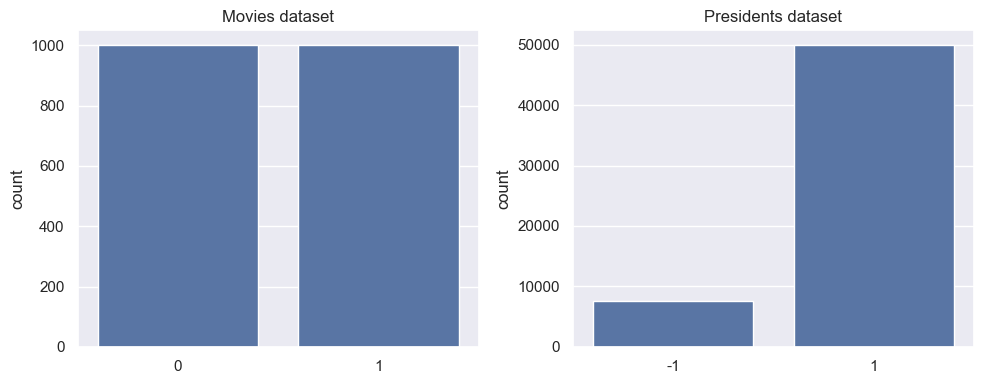

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x=classes_movies, ax=ax1)
sns.countplot(x=classes_pres, ax=ax2)

ax1.set_title("Movies dataset")
ax2.set_title("Presidents dataset")

plt.tight_layout()

_, counts= np.unique(classes_movies, return_counts=True)
print("Movies classes ratio:", counts[0]/counts[1])

_, counts= np.unique(classes_pres, return_counts=True)
print("Presidents classes ratio:", counts[1]/counts[0])

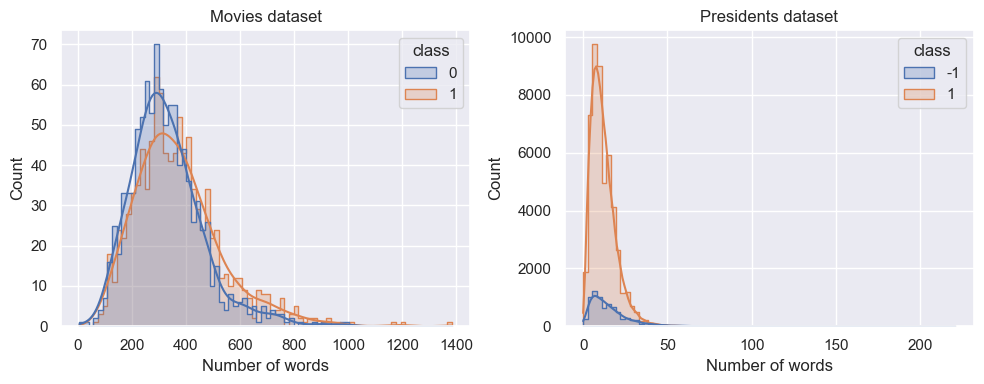

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

df_movies = pd.DataFrame(data={"length": [len(text.split()) for text in texts_movies], "class": classes_movies})
df_pres = pd.DataFrame(data={"length": [len(text.split()) for text in texts_pres], "class": classes_pres})

sns.histplot(data=df_movies, x="length", hue="class", ax=ax1, bins=80, kde=True, common_bins=True, common_norm=False, element="step")
sns.histplot(data=df_pres, x="length", hue="class", ax=ax2, bins=80, kde=True, common_bins=True, common_norm=False, element="step", palette="deep")

ax1.set_title(labels[0])
ax2.set_title(labels[1])

ax1.set_xlabel("Number of words")
ax2.set_xlabel("Number of words")

plt.tight_layout()

fig.savefig("plots/docs_legnth.pdf", bbox_inches="tight", format="pdf")

10628
7298


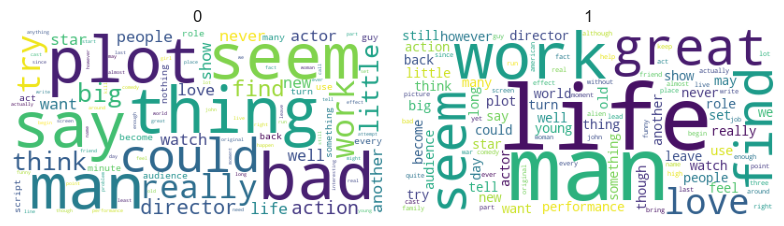

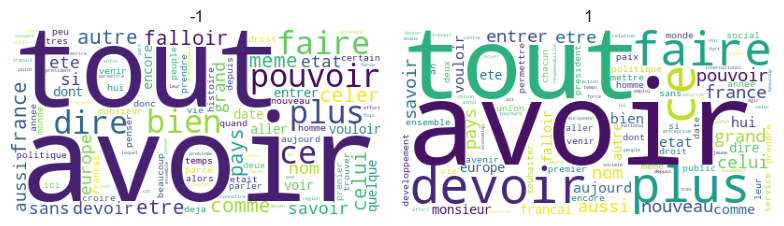

In [8]:
vectorizer = CountVectorizer(min_df=5, max_df=0.5, ngram_range=(1, 1), analyzer="word").fit(texts_movies)
matrix = vectorizer.transform(texts_movies)
vocab = vectorizer.get_feature_names_out()
eda.plot_class_wordclouds(classes_movies, matrix, vocab)
print(len(vectorizer.get_feature_names_out()))

vectorizer = CountVectorizer(min_df=5, max_df=0.5, ngram_range=(1, 1), analyzer="word").fit(texts_pres)
matrix = vectorizer.transform(texts_pres)
vocab = vectorizer.get_feature_names_out()
eda.plot_class_wordclouds(classes_pres, matrix, vocab)
print(len(vectorizer.get_feature_names_out()))

11331
17322


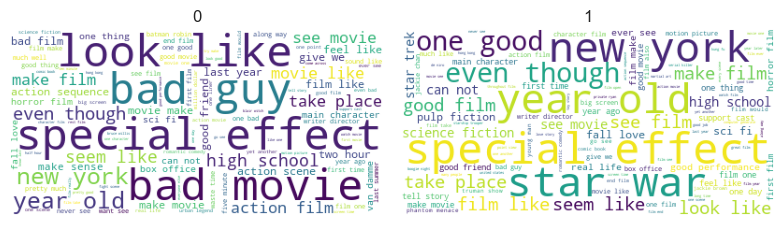

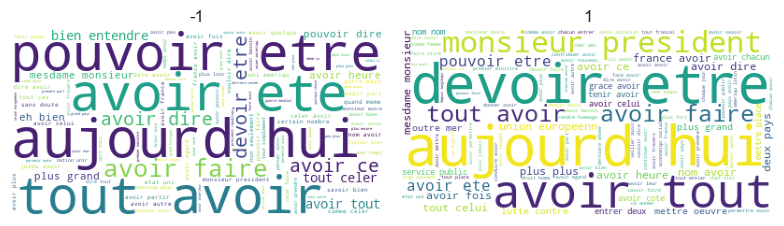

In [9]:
vectorizer = CountVectorizer(min_df=5, max_df=0.5, ngram_range=(2, 2), analyzer="word").fit(texts_movies)
matrix = vectorizer.transform(texts_movies)
vocab = vectorizer.get_feature_names_out()
eda.plot_class_wordclouds(classes_movies, matrix, vocab)
print(len(vectorizer.get_feature_names_out()))

vectorizer = CountVectorizer(min_df=5, max_df=0.5, ngram_range=(2, 2), analyzer="word").fit(texts_pres)
matrix = vectorizer.transform(texts_pres)
vocab = vectorizer.get_feature_names_out()
eda.plot_class_wordclouds(classes_pres, matrix, vocab)
print(len(vectorizer.get_feature_names_out()))

716


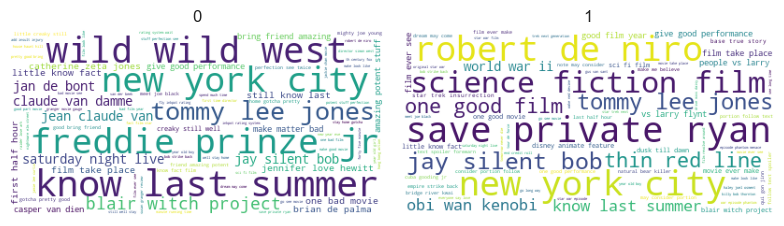

In [ ]:
vectorizer = CountVectorizer(min_df=5, max_df=0.5, ngram_range=(3, 3), analyzer="word").fit(texts_movies)
matrix = vectorizer.transform(texts_movies)
vocab = vectorizer.get_feature_names_out()
eda.plot_class_wordclouds(classes_movies, matrix, vocab)
print(len(vectorizer.get_feature_names_out()))

vectorizer = CountVectorizer(min_df=5, max_df=0.5, ngram_range=(3, 3), analyzer="word").fit(texts_pres)
matrix = vectorizer.transform(texts_pres)
vocab = vectorizer.get_feature_names_out()
eda.plot_class_wordclouds(classes_pres, matrix, vocab)
print(len(vectorizer.get_feature_names_out()))

### Zipf law

In [9]:
vec_movies = CountVectorizer(min_df=20, max_df=0.5, ngram_range=(1, 1), analyzer="word")
matrix_movies = vec_movies.fit_transform(texts_movies)
vocab_movies = vec_movies.get_feature_names_out()

vec_pres = CountVectorizer(min_df=20, max_df=0.5, ngram_range=(1, 1), analyzer="word")
matrix_pres = vec_pres.fit_transform(texts_pres)
vocab_pres = vec_pres.get_feature_names_out()

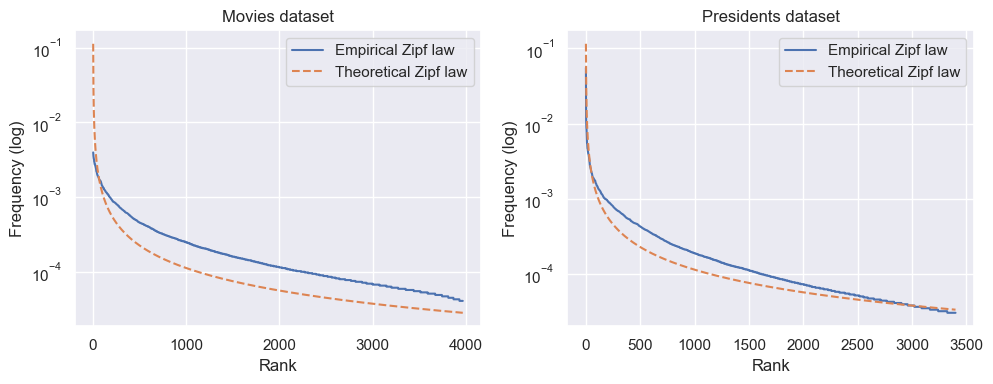

In [10]:
# Movies
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, (matrix, vocab) in enumerate([(matrix_movies, vocab_movies),
                                  (matrix_pres, vocab_pres)]):

    theo_zipf, ranks = eda.get_theo_zipf(matrix, vocab)
    emp_zipf, _ = eda.get_emp_zipf(matrix, vocab)

    axes[i].plot(ranks, emp_zipf, label="Empirical Zipf law")
    axes[i].plot(ranks, theo_zipf, linestyle="--", label="Theoretical Zipf law")
    axes[i].set_yscale("log")
    axes[i].set_title(labels[i])
    axes[i].set_xlabel("Rank")
    axes[i].set_ylabel("Frequency (log)")
    axes[i].legend()

plt.tight_layout()

### Log-odds ratio

In [11]:
vec_movies = CountVectorizer(max_df=0.8, ngram_range=(1, 2), analyzer="word", max_features=5000)
matrix_movies = vec_movies.fit_transform(texts_movies)
vocab_movies = vec_movies.get_feature_names_out()

vec_pres = CountVectorizer(max_df=0.8, ngram_range=(1, 2), analyzer="word", max_features=5000)
matrix_pres = vec_pres.fit_transform(texts_pres)
vocab_pres = vec_pres.get_feature_names_out()

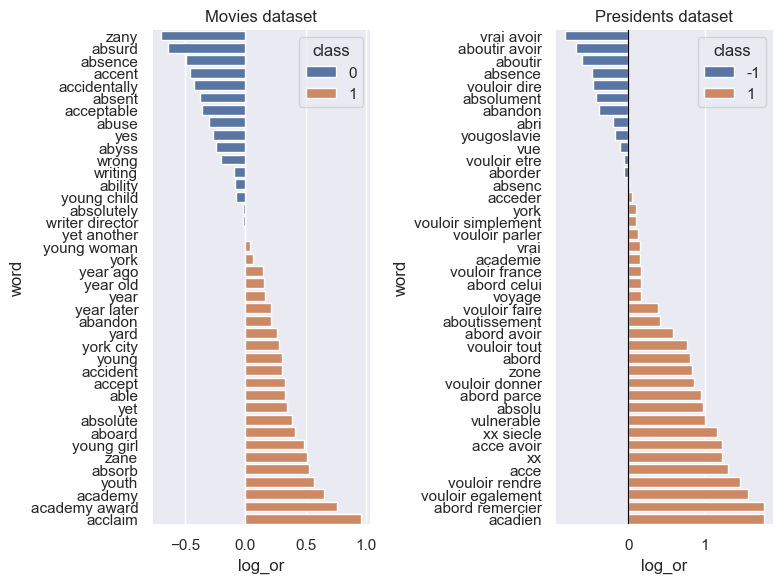

In [12]:
vals_movies = [1, 0]
df_or_movies = eda.get_log_odds_ratio(matrix_movies, vocab_movies, classes_movies, vals_movies)

vals_pres = [1, -1]
df_or_pres = eda.get_log_odds_ratio(matrix_pres, vocab_pres, classes_pres, vals_pres)

limit = 20

fig, axes = plt.subplots(1, 2, figsize=(8, 6))

for i, (df, classes_vals) in enumerate([(df_or_movies, vals_movies),
                                        (df_or_pres, vals_pres)]):
    
    df_or_top = pd.concat([df.head(limit), df.tail(limit)])
    df_or_top["class"] = np.where(df_or_top["log_or"] > 0, classes_vals[0], classes_vals[-1])
    df_or_top = df_or_top.sort_values("log_or")

    sns.barplot(data=df_or_top, x="log_or", y="word", hue="class", ax=axes[i], palette="deep")
    axes[i].set_title(labels[i])
    plt.axvline(0, color="black", linewidth=0.8)
        
plt.tight_layout()